In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)


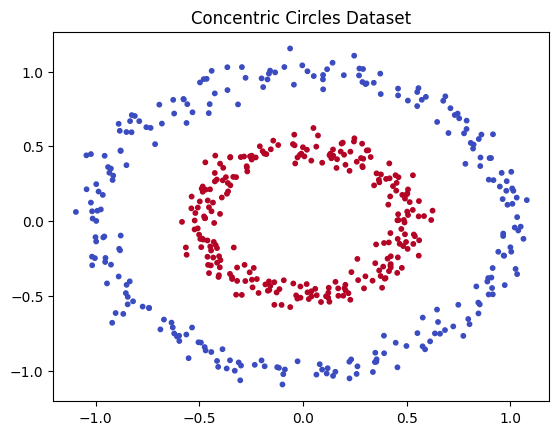

In [3]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=10)
plt.title("Concentric Circles Dataset")
plt.show()


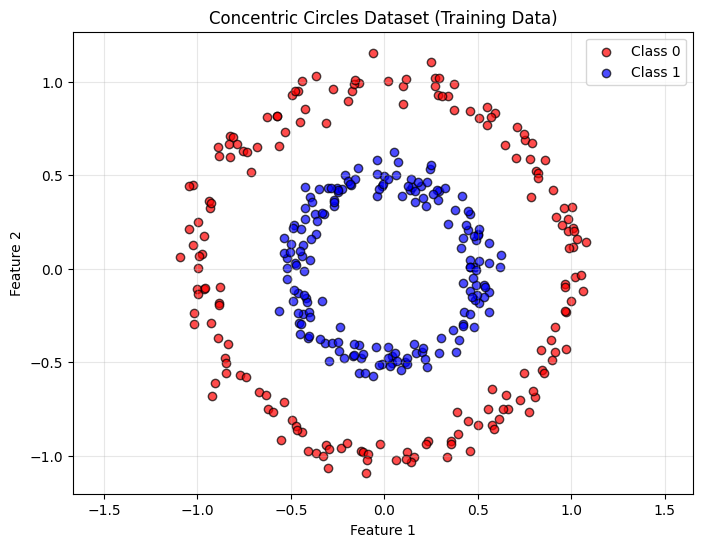

Total samples: 500
Training samples: 350
Test samples: 150
Class distribution in training: Class 0: 175, Class 1: 175


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Generate the dataset
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the training data
plt.figure(figsize=(8, 6))

# Plot class 0 (inner circle)
plt.scatter(X_train[y_train == 0][:, 0],
            X_train[y_train == 0][:, 1],
            color='red', label='Class 0', alpha=0.7, edgecolors='k')

# Plot class 1 (outer circle)
plt.scatter(X_train[y_train == 1][:, 0],
            X_train[y_train == 1][:, 1],
            color='blue', label='Class 1', alpha=0.7, edgecolors='k')

plt.title('Concentric Circles Dataset (Training Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Optional: Print dataset information
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Class distribution in training: Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")

In [5]:
svm = SVC(kernel='rbf', C=1, gamma=0.5)  # RBF kernel allows learning circular boundaries
svm.fit(X_train, y_train)

SVC(C=1, gamma=0.5)

In [6]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


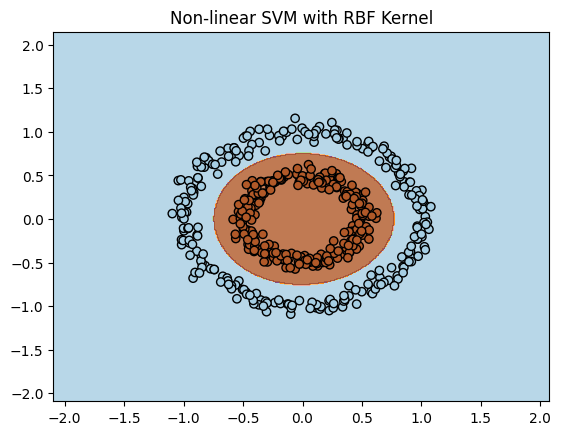

In [7]:
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title("Non-linear SVM with RBF Kernel")
    plt.show()

# Plot the decision boundary
plot_decision_boundary(X, y, svm)